In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")

if torch.cuda.is_available():
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")
    print(f"GPU 메모리: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("⚠️  GPU가 없습니다. 런타임 → 런타임 유형 변경 → T4 GPU 선택 후 재실행하세요.")

사용 디바이스: cuda
GPU 이름: Tesla T4
GPU 메모리: 14.6 GB


In [ ]:
!pip install transformers -q

In [ ]:
from google.colab import files

print("train_processed.csv 와 valid_processed.csv 를 업로드하세요.")
uploaded = files.upload()

# 업로드된 파일 확인
import os
print("\n업로드된 파일:", list(uploaded.keys()))

train_processed.csv 와 valid_processed.csv 를 업로드하세요.


Saving train_processed.csv to train_processed.csv
Saving valid_processed.csv to valid_processed.csv

업로드된 파일: ['train_processed.csv', 'valid_processed.csv']


In [ ]:
import json
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger(__name__)

# ── 파일 경로 (업로드한 파일명과 맞춰주세요) ──
TRAIN_PATH = "train_processed.csv"
VALID_PATH = "valid_processed.csv"
MODEL_DIR  = "./models/klue_bert"

# ── 컬럼명 ──
TEXT_COL  = "good_response"
LABEL_COL = "emotion_state"

# ── KLUE-BERT ──
PRETRAINED_MODEL = "klue/bert-base"

# ── 감정 레이블 ──
EMOTION_LABELS = ["분노", "슬픔", "불안", "상처", "당황", "기쁨"]
LABEL2ID       = {label: i for i, label in enumerate(EMOTION_LABELS)}
ID2LABEL       = {i: label for i, label in enumerate(EMOTION_LABELS)}
NUM_LABELS     = len(EMOTION_LABELS)

# ── 하이퍼파라미터 ──
MAX_LENGTH   = 128   # GPU 있으면 128 권장
BATCH_SIZE   = 32    # GPU 있으면 32 권장
EPOCHS       = 5
LR           = 2e-5
WARMUP_RATIO = 0.1
RANDOM_SEED  = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"설정 완료 — 디바이스: {DEVICE}")


설정 완료 — 디바이스: cuda


In [ ]:
train_df = pd.read_csv(TRAIN_PATH)
valid_df = pd.read_csv(VALID_PATH)

# 결측치 및 유효하지 않은 레이블 제거
train_df = train_df.dropna(subset=[TEXT_COL, LABEL_COL])
valid_df = valid_df.dropna(subset=[TEXT_COL, LABEL_COL])
train_df = train_df[train_df[LABEL_COL].isin(EMOTION_LABELS)].reset_index(drop=True)
valid_df = valid_df[valid_df[LABEL_COL].isin(EMOTION_LABELS)].reset_index(drop=True)

# valid → val(50%) / test(50%) 분리
val_df, test_df = train_test_split(
    valid_df, test_size=0.5, stratify=valid_df[LABEL_COL], random_state=RANDOM_SEED
)
val_df  = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# 정수 레이블 변환
for df in [train_df, val_df, test_df]:
    df["label"] = df[LABEL_COL].map(LABEL2ID)

print(f"Train: {len(train_df):,}건 | Val: {len(val_df):,}건 | Test: {len(test_df):,}건")
print(f"\n감정 분포 (Train):\n{train_df[LABEL_COL].value_counts().to_string()}")

Train: 51,630건 | Val: 3,320건 | Test: 3,321건

감정 분포 (Train):
emotion_state
불안    9320
분노    9160
상처    9143
슬픔    9125
당황    8756
기쁨    6126


In [ ]:
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts      = texts
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long),
        }


def make_dataloader(df, tokenizer, shuffle):
    dataset = EmotionDataset(
        texts      = df[TEXT_COL].astype(str).tolist(),
        labels     = df["label"].tolist(),
        tokenizer  = tokenizer,
        max_length = MAX_LENGTH,
    )
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle)


print("Dataset 클래스 정의 완료")

Dataset 클래스 정의 완료


In [ ]:
print(f"KLUE-BERT 로드 중: {PRETRAINED_MODEL}")
print("(첫 실행 시 약 400MB 다운로드 — 잠시 기다려주세요)")

tokenizer = AutoTokenizer.from_pretrained(PRETRAINED_MODEL)
model     = AutoModelForSequenceClassification.from_pretrained(
    PRETRAINED_MODEL,
    num_labels = NUM_LABELS,
    id2label   = ID2LABEL,
    label2id   = LABEL2ID,
)
model.to(DEVICE)

train_loader = make_dataloader(train_df, tokenizer, shuffle=True)
val_loader   = make_dataloader(val_df,   tokenizer, shuffle=False)
test_loader  = make_dataloader(test_df,  tokenizer, shuffle=False)

print(f"모델 로드 완료")
print(f"Train 배치 수: {len(train_loader)} | Val 배치 수: {len(val_loader)}")

KLUE-BERT 로드 중: klue/bert-base
(첫 실행 시 약 400MB 다운로드 — 잠시 기다려주세요)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on you

모델 로드 완료
Train 배치 수: 1614 | Val 배치 수: 104


In [ ]:
def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss = 0.0
    for step, batch in enumerate(loader):
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["label"].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

        if (step + 1) % 200 == 0:
            print(f"  Step {step+1}/{len(loader)} | Loss: {loss.item():.4f}")

    return total_loss / len(loader)


def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels         = batch["label"].to(DEVICE)
            outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
            preds          = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return accuracy, macro_f1, all_preds, all_labels


print("학습 함수 정의 완료")

학습 함수 정의 완료


In [ ]:
Path(MODEL_DIR).mkdir(parents=True, exist_ok=True)

optimizer    = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps,
)

print(f"학습 시작 — {EPOCHS} 에포크 | 전체 스텝: {total_steps:,} | Warmup: {warmup_steps:,}\n")

best_val_f1 = 0.0
best_epoch  = 0
history     = []

for epoch in range(1, EPOCHS + 1):
    print(f"{'─'*45}")
    print(f"Epoch {epoch} / {EPOCHS}")
    print(f"{'─'*45}")

    train_loss            = train_epoch(model, train_loader, optimizer, scheduler)
    val_acc, val_f1, _, _ = evaluate_model(model, val_loader)

    print(f"Train Loss  : {train_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")
    print(f"Val Macro F1: {val_f1:.4f}\n")

    history.append({"epoch": epoch, "train_loss": train_loss, "val_acc": val_acc, "val_f1": val_f1})

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch
        torch.save(model.state_dict(), os.path.join(MODEL_DIR, "best_model.pt"))
        print(f"✅ 최고 모델 저장 (Epoch {epoch} | Val F1: {val_f1:.4f})\n")

print(f"학습 완료 — 최고 성능: Epoch {best_epoch} (Val F1: {best_val_f1:.4f})")

학습 시작 — 5 에포크 | 전체 스텝: 8,070 | Warmup: 807

─────────────────────────────────────────────
Epoch 1 / 5
─────────────────────────────────────────────
  Step 200/1614 | Loss: 1.6588
  Step 400/1614 | Loss: 1.4867
  Step 600/1614 | Loss: 1.0285
  Step 800/1614 | Loss: 1.1448
  Step 1000/1614 | Loss: 1.2638
  Step 1200/1614 | Loss: 0.9125
  Step 1400/1614 | Loss: 1.1416
  Step 1600/1614 | Loss: 1.1261
Train Loss  : 1.3662
Val Accuracy: 0.6364
Val Macro F1: 0.6305

✅ 최고 모델 저장 (Epoch 1 | Val F1: 0.6305)

─────────────────────────────────────────────
Epoch 2 / 5
─────────────────────────────────────────────
  Step 200/1614 | Loss: 0.9944
  Step 400/1614 | Loss: 0.9888
  Step 600/1614 | Loss: 1.0727
  Step 800/1614 | Loss: 1.2162
  Step 1000/1614 | Loss: 1.2193
  Step 1200/1614 | Loss: 0.8823
  Step 1400/1614 | Loss: 1.0709
  Step 1600/1614 | Loss: 1.0054
Train Loss  : 1.1835
Val Accuracy: 0.6398
Val Macro F1: 0.6309

✅ 최고 모델 저장 (Epoch 2 | Val F1: 0.6309)

──────────────────────────────────────

In [ ]:
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, "best_model.pt"), map_location=DEVICE))
test_acc, test_f1, test_preds, test_labels = evaluate_model(model, test_loader)

label_names = [ID2LABEL[i] for i in range(NUM_LABELS)]
report = classification_report(test_labels, test_preds, target_names=label_names, digits=4)
cm     = confusion_matrix(test_labels, test_preds)

print("=" * 55)
print("  📋  최종 Test 결과")
print("=" * 55)
print(f"\nTest Accuracy  : {test_acc:.4f}  ({test_acc*100:.1f}%)")
print(f"Test Macro F1  : {test_f1:.4f}")
print(f"\n{report}")

  📋  최종 Test 결과

Test Accuracy  : 0.6570  (65.7%)
Test Macro F1  : 0.6524

              precision    recall  f1-score   support

          분노     0.6548    0.6455    0.6501       629
          슬픔     0.5939    0.6627    0.6264       501
          불안     0.6123    0.6409    0.6263       557
          상처     0.5143    0.5368    0.5253       503
          당황     0.6138    0.5611    0.5862       524
          기쁨     0.9423    0.8616    0.9002       607

    accuracy                         0.6570      3321
   macro avg     0.6553    0.6514    0.6524      3321
weighted avg     0.6633    0.6570    0.6593      3321



/tmp/ipykernel_1563/1128284384.py:20: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/1128284384.py:20: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/1128284384.py:20: UserWarning: Glyph 49836 (\N{HANGUL SYLLABLE SEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/1128284384.py:20: UserWarning: Glyph 54548 (\N{HANGUL SYLLABLE PEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/1128284384.py:20: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/1128284384.py:20: UserWarning: Glyph 50504 (\N{HANGUL SYLLABLE AN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/1128284384.py:20: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_

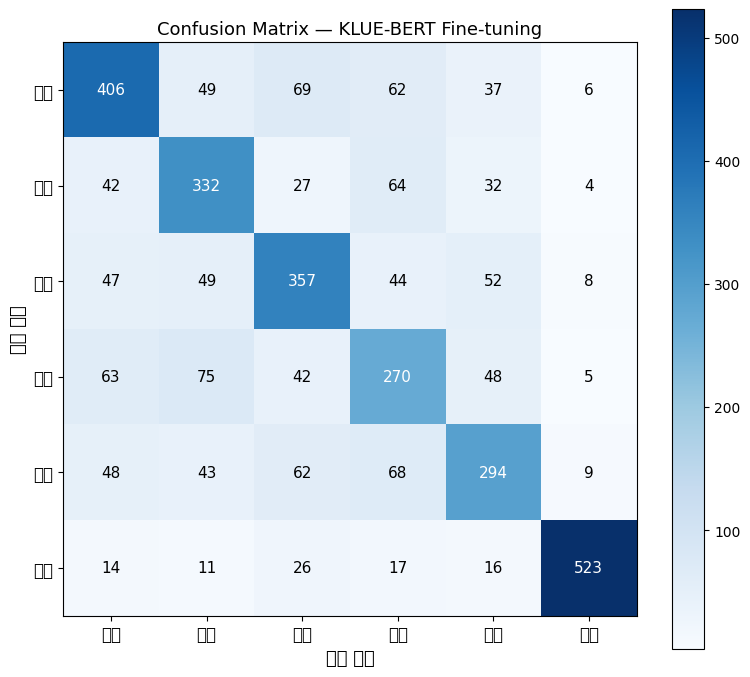

Confusion Matrix 저장 완료


In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(EMOTION_LABELS)))
ax.set_yticks(range(len(EMOTION_LABELS)))
ax.set_xticklabels(EMOTION_LABELS, fontsize=12)
ax.set_yticklabels(EMOTION_LABELS, fontsize=12)
ax.set_xlabel("예측 감정", fontsize=13)
ax.set_ylabel("실제 감정", fontsize=13)
ax.set_title("Confusion Matrix — KLUE-BERT Fine-tuning", fontsize=13)

thresh = cm.max() / 2.0
for i in range(len(EMOTION_LABELS)):
    for j in range(len(EMOTION_LABELS)):
        ax.text(j, i, str(cm[i, j]),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black", fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "confusion_matrix.png"), dpi=150)
plt.show()
print("Confusion Matrix 저장 완료")


/tmp/ipykernel_1563/1128284384.py:20: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/1128284384.py:20: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/1128284384.py:20: UserWarning: Glyph 49836 (\N{HANGUL SYLLABLE SEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/1128284384.py:20: UserWarning: Glyph 54548 (\N{HANGUL SYLLABLE PEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/1128284384.py:20: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/1128284384.py:20: UserWarning: Glyph 50504 (\N{HANGUL SYLLABLE AN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/1128284384.py:20: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_

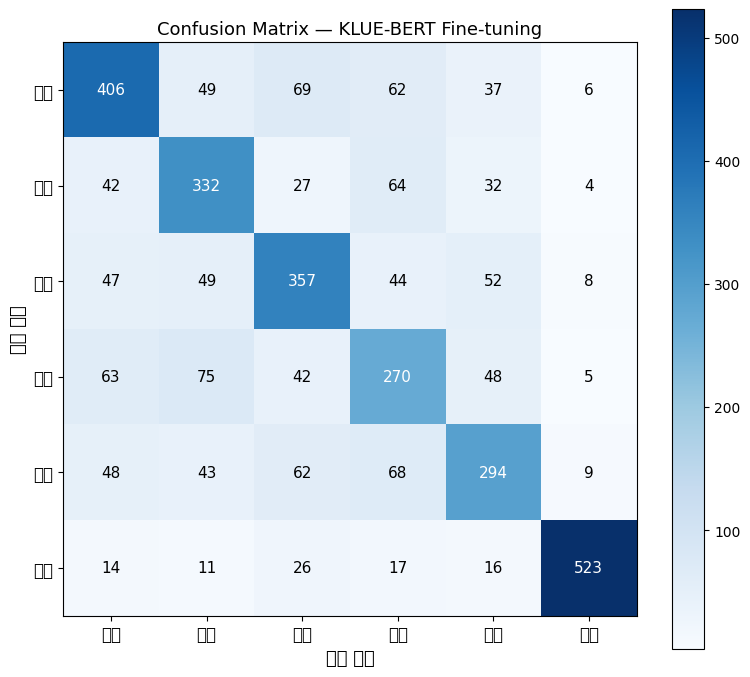

Confusion Matrix 저장 완료


In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(EMOTION_LABELS)))
ax.set_yticks(range(len(EMOTION_LABELS)))
ax.set_xticklabels(EMOTION_LABELS, fontsize=12)
ax.set_yticklabels(EMOTION_LABELS, fontsize=12)
ax.set_xlabel("예측 감정", fontsize=13)
ax.set_ylabel("실제 감정", fontsize=13)
ax.set_title("Confusion Matrix — KLUE-BERT Fine-tuning", fontsize=13)

thresh = cm.max() / 2.0
for i in range(len(EMOTION_LABELS)):
    for j in range(len(EMOTION_LABELS)):
        ax.text(j, i, str(cm[i, j]),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black", fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "confusion_matrix.png"), dpi=150)
plt.show()
print("Confusion Matrix 저장 완료")


/tmp/ipykernel_1563/1360057763.py:23: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/1360057763.py:23: UserWarning: Glyph 45733 (\N{HANGUL SYLLABLE NEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/1360057763.py:24: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(MODEL_DIR, "training_curve.png"), dpi=150)
/tmp/ipykernel_1563/1360057763.py:24: UserWarning: Glyph 45733 (\N{HANGUL SYLLABLE NEUNG}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(MODEL_DIR, "training_curve.png"), dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45733 (\N{HANGUL SYLLABLE 

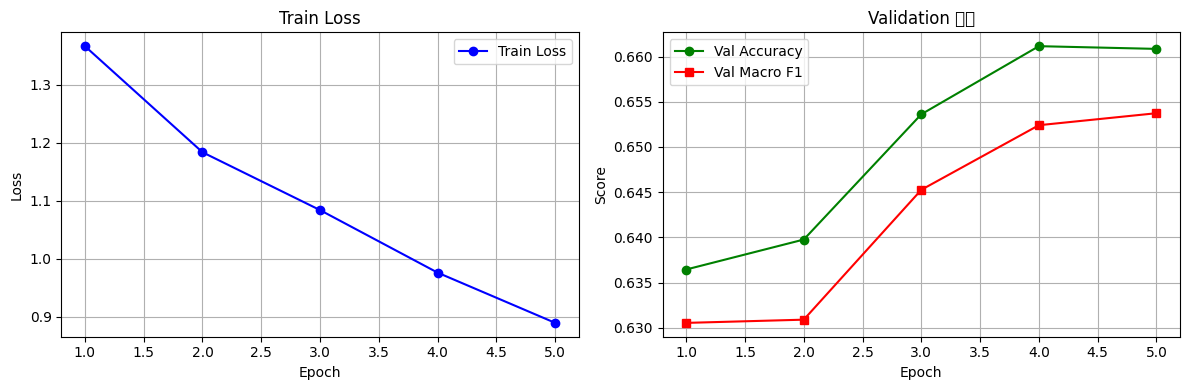

학습 곡선 저장 완료


In [ ]:
epochs_list = [h["epoch"] for h in history]
losses      = [h["train_loss"] for h in history]
val_accs    = [h["val_acc"] for h in history]
val_f1s     = [h["val_f1"] for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_list, losses, "b-o", label="Train Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Train Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_list, val_accs, "g-o", label="Val Accuracy")
ax2.plot(epochs_list, val_f1s,  "r-s", label="Val Macro F1")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Score")
ax2.set_title("Validation 성능")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "training_curve.png"), dpi=150)
plt.show()
print("학습 곡선 저장 완료")

In [ ]:
import shutil
# 모델 파일들을 zip으로 묶어서 다운로드
shutil.make_archive("klue_bert_model", "zip", MODEL_DIR)
files.download("klue_bert_model.zip")
print("모델 다운로드 완료!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

모델 다운로드 완료!


In [ ]:
def predict(text: str) -> dict:
    """
    텍스트 입력 → 감정 예측

    Returns
    -------
    {"emotion": str, "confidence": float, "all_scores": dict}
    """
    model.eval()
    inputs = tokenizer(
        text,
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    )
    input_ids      = inputs["input_ids"].to(DEVICE)
    attention_mask = inputs["attention_mask"].to(DEVICE)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1)[0].cpu().numpy()

    pred_idx    = int(np.argmax(probs))
    emotion     = ID2LABEL[pred_idx]
    confidence  = float(probs[pred_idx])
    all_scores  = {ID2LABEL[i]: round(float(probs[i]), 4) for i in range(NUM_LABELS)}

    return {"emotion": emotion, "confidence": confidence, "all_scores": all_scores}


# 테스트
test_sentences = [
    "취업에 대한 질문이 당혹스러우셨군요..",
    "회사에서 합격 통보받았다가 다시 입사 취소되어서 당혹스러우시군요.",
    "온몸에 마비될 것 같은 기분이 드신다니 현재 어떤 상황인지 여쭤봐도 될까요?",
]

print("=" * 45)
print("  추론 테스트")
print("=" * 45)
for text in test_sentences:
    result = predict(text)
    print(f"\n입력: {text}")
    print(f"예측: {result['emotion']}  (확신도: {result['confidence']*100:.1f}%)")
    print(f"전체: {result['all_scores']}")


  추론 테스트

입력: 취업에 대한 질문이 당혹스러우셨군요..
예측: 불안  (확신도: 76.2%)
전체: {'분노': 0.0193, '슬픔': 0.0067, '불안': 0.7624, '상처': 0.0094, '당황': 0.201, '기쁨': 0.0012}

입력: 회사에서 합격 통보받았다가 다시 입사 취소되어서 당혹스러우시군요.
예측: 불안  (확신도: 93.9%)
전체: {'분노': 0.0044, '슬픔': 0.0033, '불안': 0.9394, '상처': 0.0135, '당황': 0.0389, '기쁨': 0.0005}

입력: 온몸에 마비될 것 같은 기분이 드신다니 현재 어떤 상황인지 여쭤봐도 될까요?
예측: 슬픔  (확신도: 93.3%)
전체: {'분노': 0.0067, '슬픔': 0.9331, '불안': 0.029, '상처': 0.0082, '당황': 0.0046, '기쁨': 0.0183}
